In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load dataset

df = pd.read_csv('Nassau Candy Distributor.csv')

# View first rows
print(df.head())

   Row ID                      Order ID  Order Date   Ship Date  \
0       1  US-2021-103800-CHO-MIL-31000  03-01-2024  30-06-2026   
1       2  US-2021-112326-CHO-TRI-54000  04-01-2024  01-07-2026   
2       3  US-2021-112326-CHO-NUT-13000  04-01-2024  01-07-2026   
3       4  US-2021-112326-CHO-SCR-58000  04-01-2024  01-07-2026   
4       5  US-2021-141817-CHO-TRI-54000  05-01-2024  05-07-2026   

        Ship Mode  Customer ID Country/Region          City State/Province  \
0  Standard Class       103800  United States       Houston          Texas   
1  Standard Class       112326  United States    Naperville       Illinois   
2  Standard Class       112326  United States    Naperville       Illinois   
3  Standard Class       112326  United States    Naperville       Illinois   
4  Standard Class       141817  United States  Philadelphia   Pennsylvania   

  Postal Code   Division    Region     Product ID  \
0       77095  Chocolate  Interior  CHO-MIL-31000   
1       60540  Chocola

In [2]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True,
    errors='coerce'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True,
    errors='coerce'
)
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05


In [3]:
df['Lead Time'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

df[['Order Date', 'Ship Date', 'Lead Time']].head()

,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [4]:
df.describe()
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
Lead Time         0
dtype: int64

In [5]:
factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df['Factory'] = df['Product Name'].map(factory_mapping)
df[['Product Name', 'Factory']].head(10)

,Product Name,Factory
0,Wonka Bar - Milk Chocolate,Wicked Choccy's
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's
7,Wonka Bar - Milk Chocolate,Wicked Choccy's
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts
9,Wonka Bar - Milk Chocolate,Wicked Choccy's


In [6]:
df['Route'] = (
    df['Factory'] + " → " + df['State/Province']
)
df[['Factory', 'State/Province', 'Route']].head(10)

,Factory,State/Province,Route
0,Wicked Choccy's,Texas,Wicked Choccy's → Texas
1,Wicked Choccy's,Illinois,Wicked Choccy's → Illinois
2,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
3,Lot's O' Nuts,Illinois,Lot's O' Nuts → Illinois
4,Wicked Choccy's,Pennsylvania,Wicked Choccy's → Pennsylvania
5,Lot's O' Nuts,Kentucky,Lot's O' Nuts → Kentucky
6,Wicked Choccy's,Kentucky,Wicked Choccy's → Kentucky
7,Wicked Choccy's,Georgia,Wicked Choccy's → Georgia
8,Lot's O' Nuts,Kentucky,Lot's O' Nuts → Kentucky
9,Wicked Choccy's,Kentucky,Wicked Choccy's → Kentucky


In [7]:
route_analysis = df.groupby('Route').agg(
    Average_Lead_Time=('Lead Time', 'mean'),
    Total_Shipments=('Order ID', 'count')
).reset_index()
route_analysis.head(10)

,Route,Average_Lead_Time,Total_Shipments
0,Lot's O' Nuts → Alabama,1295.205882,34
1,Lot's O' Nuts → Alberta,1273.875000,16
2,Lot's O' Nuts → Arizona,1306.198198,111
3,Lot's O' Nuts → Arkansas,1285.354839,31
4,Lot's O' Nuts → British Columbia,1273.777778,18
5,Lot's O' Nuts → California,1316.910222,1125
6,Lot's O' Nuts → Colorado,1347.533981,103
7,Lot's O' Nuts → Connecticut,1420.553191,47
8,Lot's O' Nuts → Delaware,1273.302326,43
9,Lot's O' Nuts → District of Columbia,1365.875000,8


In [8]:
fastest_routes = route_analysis.sort_values(
    by='Average_Lead_Time'
).head(10)

fastest_routesfastest_routes = route_analysis.sort_values(
    by='Average_Lead_Time'
).head(10)

fastest_routes

,Route,Average_Lead_Time,Total_Shipments
76,Secret Factory → Nebraska,906.0,1
80,Secret Factory → New Mexico,906.0,2
121,The Other Factory → Louisiana,907.0,1
115,The Other Factory → Connecticut,907.5,2
158,Wicked Choccy's → Maine,908.0,2
75,Secret Factory → Mississippi,908.0,1
70,Secret Factory → Louisiana,908.5,2
64,Secret Factory → Delaware,909.0,1
88,Secret Factory → South Carolina,909.0,1
74,Secret Factory → Minnesota,909.0,1


In [9]:
slowest_routes = route_analysis.sort_values(
    by='Average_Lead_Time',
    ascending=False
).head(10)

slowest_routes

,Route,Average_Lead_Time,Total_Shipments
103,Sugar Shack → New Jersey,1642.0,1
78,Secret Factory → New Hampshire,1641.0,1
98,Sugar Shack → Connecticut,1641.0,1
194,Wicked Choccy's → West Virginia,1639.0,2
37,Lot's O' Nuts → North Dakota,1638.2,5
97,Sugar Shack → California,1638.0,1
110,Sugar Shack → Washington,1638.0,1
63,Secret Factory → Connecticut,1638.0,1
125,The Other Factory → Nevada,1638.0,1
105,Sugar Shack → Ohio,1637.5,2


In [10]:
ship_mode_analysis = df.groupby('Ship Mode').agg(
    Average_Lead_Time=('Lead Time', 'mean'),
    Total_Shipments=('Order ID', 'count')
).reset_index()
ship_mode_analysis

,Ship Mode,Average_Lead_Time,Total_Shipments
0,First Class,1338.275840,1548
1,Same Day,1333.442413,547
2,Second Class,1323.845376,1979
3,Standard Class,1314.334641,6120


In [11]:
import matplotlib.pyplot as plt

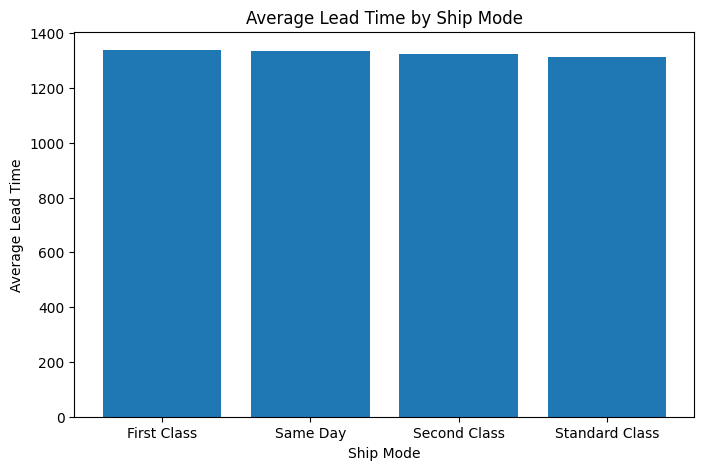

In [12]:
plt.figure(figsize=(8,5))

plt.bar(
    ship_mode_analysis['Ship Mode'],
    ship_mode_analysis['Average_Lead_Time']
)

plt.title('Average Lead Time by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Average Lead Time')

plt.show()

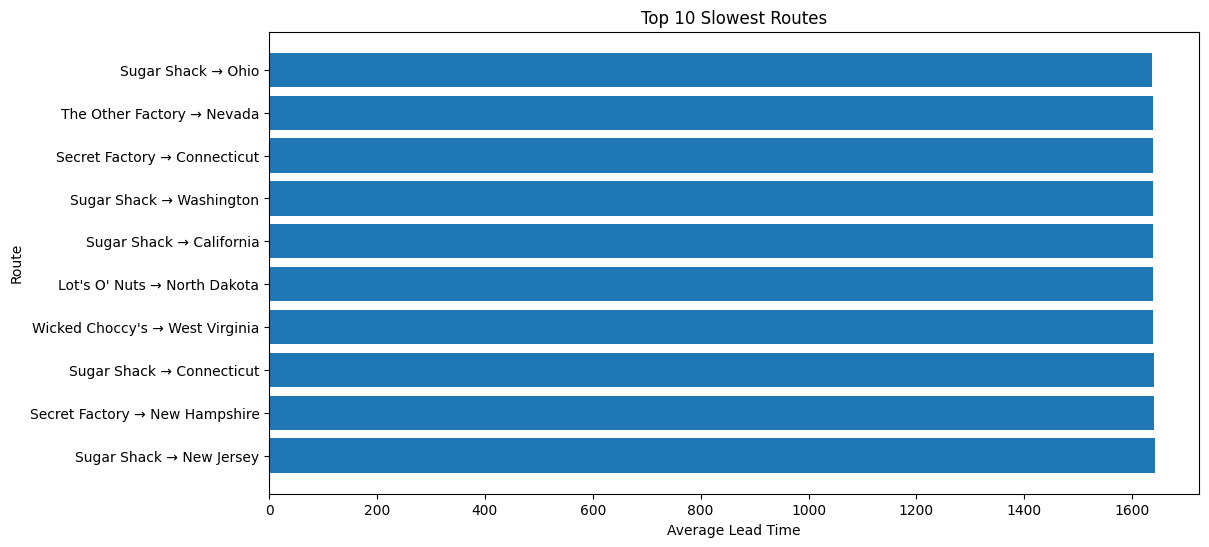

In [13]:
# Create chart size
plt.figure(figsize=(12,6))

# Horizontal bar chart
plt.barh(
    slowest_routes['Route'],
    slowest_routes['Average_Lead_Time']
)

# Chart title
plt.title('Top 10 Slowest Routes')

# X-axis label
plt.xlabel('Average Lead Time')

# Y-axis label
plt.ylabel('Route')

# Display chart
plt.show()

In [14]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead Time', 'Factory',
       'Route'],
      dtype='object')

In [15]:
df['Lead Time'] = (
    pd.to_datetime(df['Ship Date'], dayfirst=True)
    -
    pd.to_datetime(df['Order Date'], dayfirst=True)
).dt.days

In [16]:
state_analysis = df.groupby('State/Province').agg(
    Average_Lead_Time=('Lead Time', 'mean'),
    Total_Shipments=('Order ID', 'count')
).reset_index()
state_analysis.head(10)

,State/Province,Average_Lead_Time,Total_Shipments
0,Alabama,1291.278689,61
1,Alberta,1274.076923,26
2,Arizona,1309.214286,224
3,Arkansas,1285.733333,60
4,British Columbia,1290.318182,22
5,California,1318.427286,2001
6,Colorado,1337.186813,182
7,Connecticut,1357.548780,82
8,Delaware,1269.750000,96
9,District of Columbia,1347.700000,10


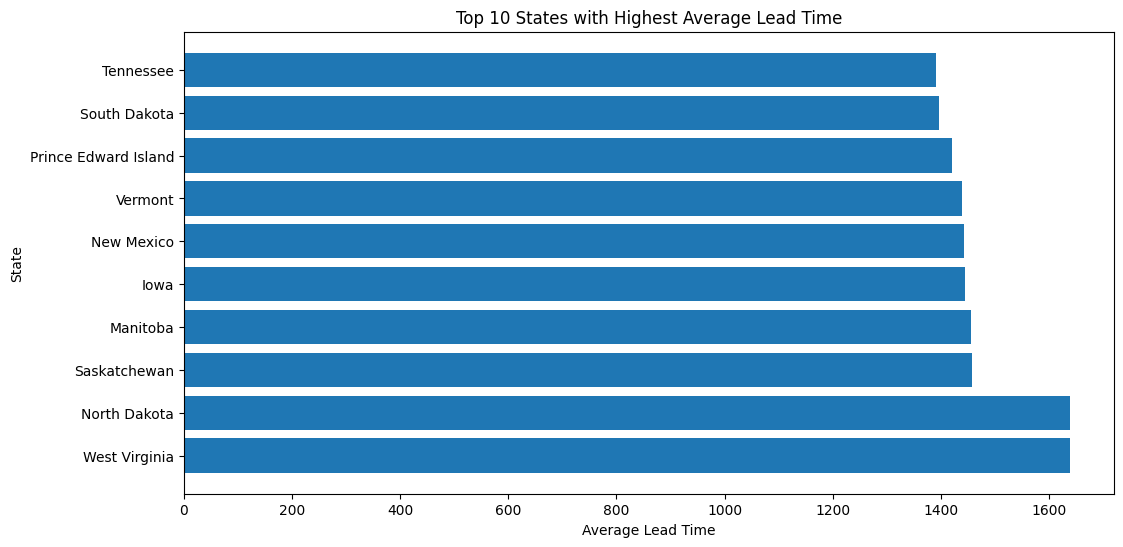

In [17]:
# Sort states by average lead time
top_states = state_analysis.sort_values(
    by='Average_Lead_Time',
    ascending=False
).head(10)

# Create figure
plt.figure(figsize=(12,6))

# Horizontal bar chart
plt.barh(
    top_states['State/Province'],
    top_states['Average_Lead_Time']
)

# Chart title
plt.title('Top 10 States with Highest Average Lead Time')

# X-axis label
plt.xlabel('Average Lead Time')

# Y-axis label
plt.ylabel('State')

# Display chart
plt.show()

In [18]:
# Define delay threshold
delay_threshold = 1300

# Create delayed shipment column
df['Delayed'] = df['Lead Time'] > delay_threshold

In [19]:
# Calculate delay percentage
delay_percentage = (
    df['Delayed'].mean()
) * 100

print("Delay Percentage:", delay_percentage)

Delay Percentage: 33.14694918579556


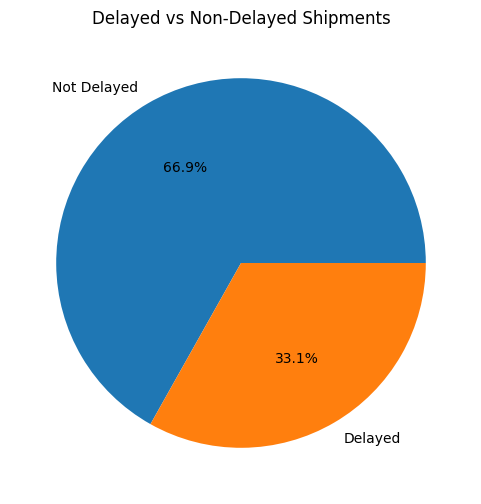

In [20]:
# Count delayed and non-delayed shipments
delay_counts = df['Delayed'].value_counts()

# Create chart
plt.figure(figsize=(6,6))

# Pie chart
plt.pie(
    delay_counts,
    labels=['Not Delayed', 'Delayed'],
    autopct='%1.1f%%'
)

# Chart title
plt.title('Delayed vs Non-Delayed Shipments')

# Display chart
plt.show()

In [21]:
region_analysis = df.groupby('Region').agg(
    Average_Lead_Time=('Lead Time', 'mean'),
    Total_Shipments=('Order ID', 'count')
).reset_index()
region_analysis

,Region,Average_Lead_Time,Total_Shipments
0,Atlantic,1322.745144,2986
1,Gulf,1311.374691,1620
2,Interior,1323.091221,2335
3,Pacific,1322.194897,3253


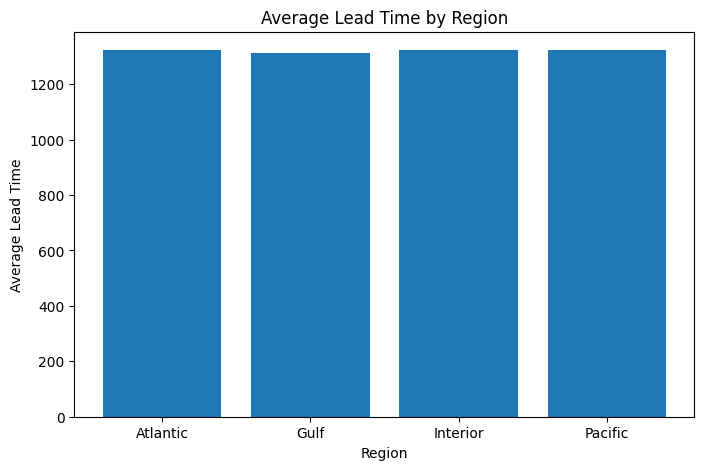

In [22]:
# Create chart size
plt.figure(figsize=(8,5))

# Bar chart
plt.bar(
    region_analysis['Region'],
    region_analysis['Average_Lead_Time']
)

# Chart title
plt.title('Average Lead Time by Region')

# X-axis label
plt.xlabel('Region')

# Y-axis label
plt.ylabel('Average Lead Time')

# Display chart
plt.show()

In [23]:
# Sort states by shipment count
top_volume_states = state_analysis.sort_values(
    by='Total_Shipments',
    ascending=False
).head(10)

top_volume_states

,State/Province,Average_Lead_Time,Total_Shipments
5,California,1318.427286,2001
34,New York,1324.493794,1128
51,Texas,1310.305584,985
43,Pennsylvania,1324.199319,587
55,Washington,1360.662055,506
13,Illinois,1323.150407,492
39,Ohio,1325.733475,469
10,Florida,1311.396867,383
23,Michigan,1300.560784,255
36,North Carolina,1334.883534,249


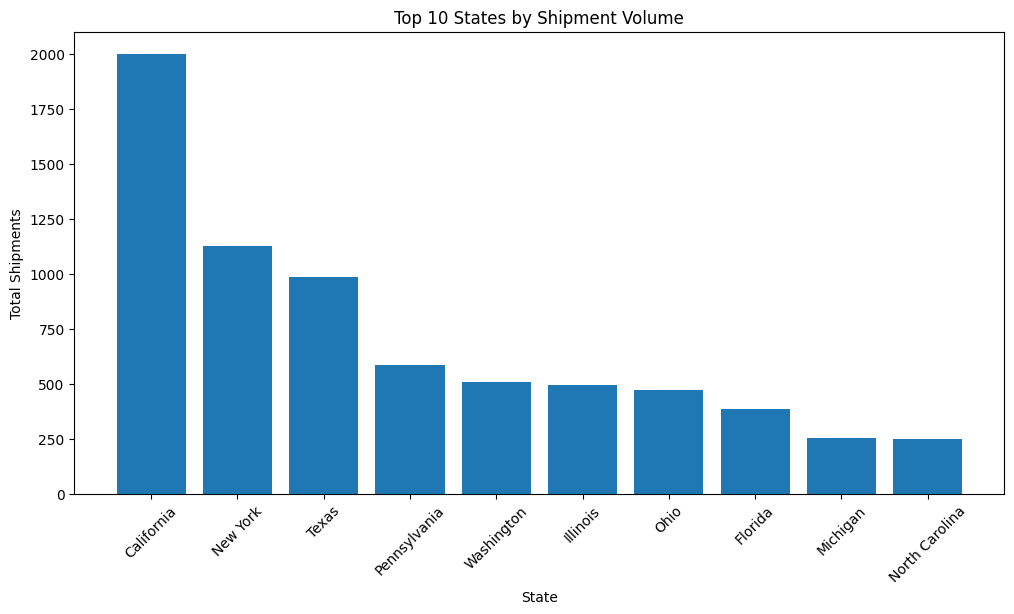

In [24]:
# Create figure size
plt.figure(figsize=(12,6))

# Bar chart
plt.bar(
    top_volume_states['State/Province'],
    top_volume_states['Total_Shipments']
)

# Chart title
plt.title('Top 10 States by Shipment Volume')

# X-axis label
plt.xlabel('State')

# Y-axis label
plt.ylabel('Total Shipments')

# Rotate state names
plt.xticks(rotation=45)

# Display chart
plt.show()